# Diego's Workspace

Diego, this is your notebook. Work on your model here.

In [1]:
# import required libraries
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer



# Exploring the Data

In [2]:
data = pd.read_csv('E:/machine_learning_1/ML2_group_assignment/ML2-GroupProject/raw/mushrooms.csv')

data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
data.describe().T

,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [5]:
data.shape

(8124, 23)

In [6]:
data.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

class
e    0.517971
p    0.482029
Name: proportion, dtype: float64

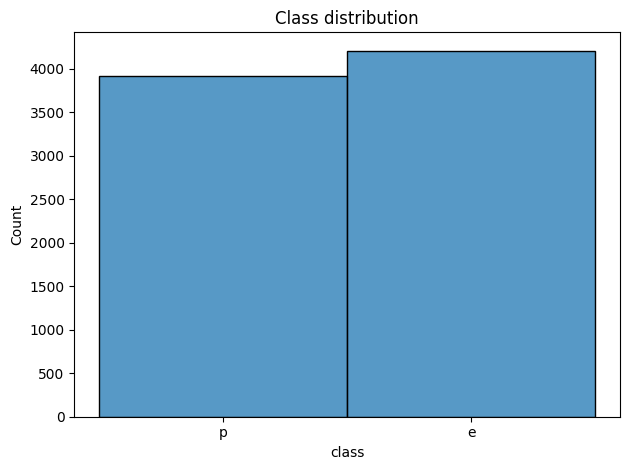

In [7]:
sns.histplot(data['class'])
plt.title('Class distribution')
plt.tight_layout()

# get the percentage for each class 
data['class'].value_counts(normalize=True)

### Nominal and Ordinal Features 
- **Nominal**: Categories with no natural order
- **Ordinal**: Categories with a meaningful order 
---------------------------------------------------

- Nominal Example: `cap-color` (red, brown, green...) -> red is not "greater than" brown
- Ordinal Example: `ring-number` (none < one < two) -> there's a clear ranking

---------------------------------------------------
- The mushrooms dataset has mostly nominal features but also contains ordinary. 
- Its important to recognize which is which as we need to encode the variables as currently its written in text and some algorithms will not be able to run 

In [8]:
data.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [9]:
nominal_features = ['cap-shape', 'cap-surface', 'cap-color',
                    'bruises', 'odor', 'gill-attachment', 'gill-size',
                    'gill-color', 'stalk-shape', 'stalk-root',
                    'stalk-surface-above-ring', 'stalk-surface-below-ring',
                    'stalk-color-above-ring', 'stalk-color-below-ring',
                    'veil-type', 'veil-color', 'ring-type',
                    'spore-print-color', 'population', 'habitat']

ordinal_features = ['gill-spacing', 'ring-number']

# Train / Test / Validation split

In [10]:
# Separate features and target
X = data.drop(columns=['class'])
y = data['class'].map({
    'p': 0,
    'e': 1
})

# Step 1: Split off test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Split remaining into train (64%) and validation (16%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

print(f'Train size:      {X_train.shape[0]} ({X_train.shape[0]/len(X):.0%})')
print(f'Validation size: {X_val.shape[0]} ({X_val.shape[0]/len(X):.0%})')
print(f'Test size:       {X_test.shape[0]} ({X_test.shape[0]/len(X):.0%})')

Train size:      5199 (64%)
Validation size: 1300 (16%)
Test size:       1625 (20%)


In [11]:
# defining the ordinal categories explicitly to apply the correct order (BASED ON THE COLUMN INFO ON KAGGLE)

ordinal_categories = [['c', 'w', 'd'],  # grill-spacing: close < crowded < distant
                      ['n', 'o', 't']]  # ring-number: none < one < two

preprocessor = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), nominal_features),
    ('ordinal', OrdinalEncoder(categories=ordinal_categories), ordinal_features),
])

# Fit ONLY on train, transform all three
# by fitting on the train data WE AVOID LEAKAGE
X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded   = preprocessor.transform(X_val)
X_test_encoded  = preprocessor.transform(X_test)

print(f'Encoded train shape: {X_train_encoded.shape}')


Encoded train shape: (5199, 114)


## Feature Importance 

### Why are we encoding again? 

 `preprocessor` (ColumnTransformer) -> for model training

Uses  `OneHotEncoder` on nominal features -> expands columns (e.g.  `cap-color` becomes 10 binary columns)
After OHE you lose the original column names, so  `.corr()` becomes messy and hard to read

 `encoder_corr` (OrdinalEncoder on everything) -> just for correlation analysis

Keeps all features as single columns with their original names
Makes the heatmap readable

In [15]:
encoder_corr = OrdinalEncoder()
X_train_corr = pd.DataFrame(
    encoder_corr.fit_transform(X_train),
    columns=X_train.columns
)

In [16]:
# get feature correlation

corr = X_train_corr.corr()

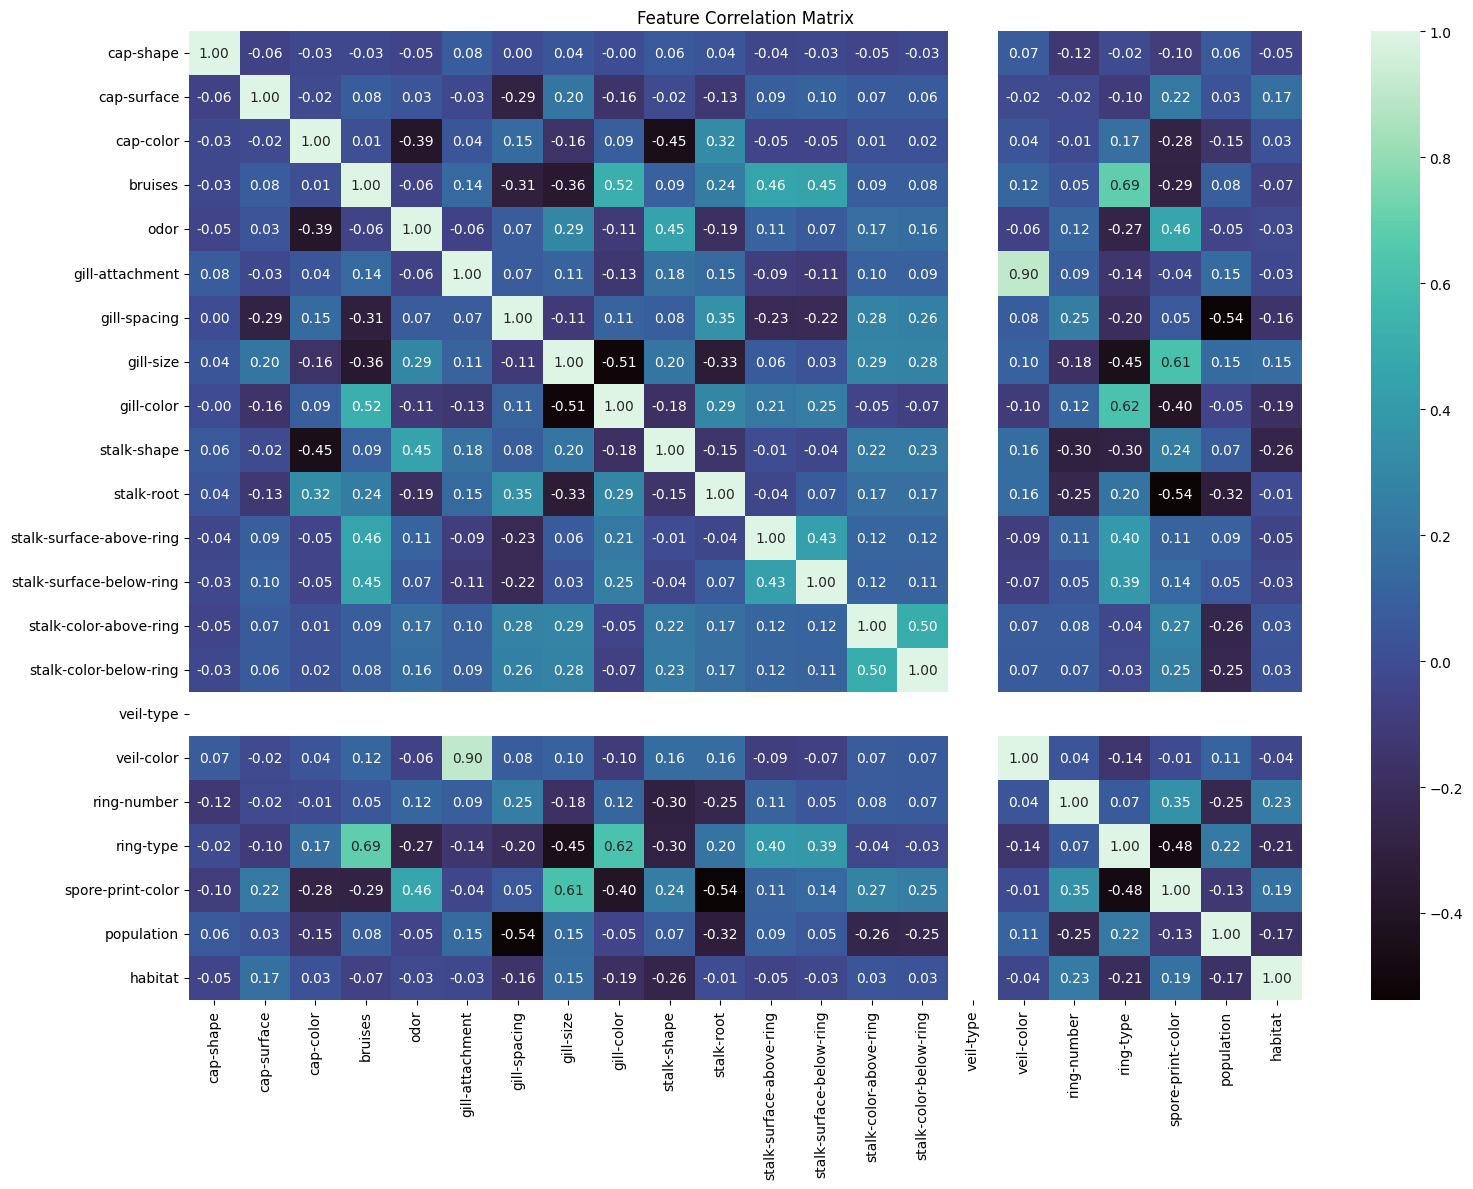

In [17]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='mako')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Tuning hyperparameters

# Things to do for next time
1. Dimensionality reduction how can we incorporate it 
- review the code and know wtf is going on so i can explain it to the team 
